# **Importing Dependencies**

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **DATA CLEANING**

In [84]:
# Data Loading
df = pd.read_csv("/content/noshowappointments - noshowappointments.csv")

In [85]:
# Checking Shape
df.shape

(110527, 14)

In [86]:
# checking info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110520 non-null  float64
 6   Neighbourhood   110520 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(2), int64(7), object(5)
memory usage: 11.8+ MB


In [87]:
# Checking Missing values
print(df.isnull().sum())

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               7
Neighbourhood     7
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


In [88]:
# Dropping Missing Values
df = df.dropna()

In [89]:
# Checking Duplicates
print(df.duplicated().sum())

0


In [90]:
# rechecking missing values
print(df.isnull().sum())

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


In [91]:
# Correcting column name inconsistencies
df.rename(columns={'No-show': 'No_show'}, inplace=True)

In [92]:
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No_show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62.0,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62.0,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8.0,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56.0,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596266e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51.0,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557663e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21.0,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213493e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38.0,MARIA ORTIZ,0,0,0,0,0,1,No


In [93]:
# Checking inconsistency in Age
df[df['Age'] < 0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No_show
99832,4.659432e+14,5775010,F,2016-06-06T08:58:13Z,2016-06-06T00:00:00Z,-1.0,ROMÃO,0,0,0,0,0,0,No


In [94]:
# Fixing Negative Age
df = df[df['Age'] >= 0]

In [95]:
# Converting Date Column and checking appointment inconsistency

df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

df[df['AppointmentDay'] < df['ScheduledDay']]

/tmp/ipython-input-2383647238.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
/tmp/ipython-input-2383647238.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No_show
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62.0,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56.0,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62.0,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8.0,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56.0,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110511,8.235996e+11,5786742,F,2016-06-08 08:50:20+00:00,2016-06-08 00:00:00+00:00,14.0,MARIA ORTIZ,0,0,0,0,0,0,No
110512,9.876246e+13,5786368,F,2016-06-08 08:20:01+00:00,2016-06-08 00:00:00+00:00,41.0,MARIA ORTIZ,0,0,0,0,0,0,No
110513,8.674778e+13,5785964,M,2016-06-08 07:52:55+00:00,2016-06-08 00:00:00+00:00,2.0,ANTÔNIO HONÓRIO,0,0,0,0,0,0,No
110514,2.695685e+12,5786567,F,2016-06-08 08:35:31+00:00,2016-06-08 00:00:00+00:00,58.0,MARIA ORTIZ,0,0,0,0,0,0,No


In [96]:
# fixing appointment inconsistency
df = df[df['AppointmentDay'] >= df['ScheduledDay']]
df.shape

(71949, 14)

In [97]:
# Checking inconsistency in Gender
df['Gender'].unique()

array(['F', 'M', 'Fml', 'Othr', 'Femal', 'Fe', 'Ml', 'O', 'Other',
       'Female', 'Male', 'Mal'], dtype=object)

In [98]:
# Fixing inconsistency in Gender
# Convert to lowercase first
df['Gender'] = df['Gender'].str.lower()

# Replace inconsistent values
df['Gender'] = df['Gender'].replace({
    'm': 'Male',
    'male': 'Male',
    'ml': 'Male',
    'mal': 'Male',

    'f': 'Female',
    'female': 'Female',
    'fml': 'Female',
    'femal': 'Female',
    'fe': 'Female',

    'othr': 'Other',
    'other': 'Other',
    'o': 'Other'
})

# Check again
df['Gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [99]:
# Checking Target Column Inconsistency
df['No_show'].unique()

array(['No', 'Yes'], dtype=object)

# **DESCRIPTIVE ANALYSIS**

In [100]:
# Total Records
total_records = len(df)
print("Total Records:", total_records)

Total Records: 71949


In [101]:
# Appointment Status Split
Appointment_Status = df['No_show'].value_counts()
print(Appointment_Status)

No_show
No     51430
Yes    20519
Name: count, dtype: int64


In [102]:
# Neighbourhood Wise Counts
neighbourhood_counts = df['Neighbourhood'].value_counts()
print(neighbourhood_counts)

Neighbourhood
JARDIM CAMBURI                 5212
MARIA ORTIZ                    3730
RESISTÊNCIA                    2816
JARDIM DA PENHA                2654
ITARARÉ                        2381
                               ... 
PONTAL DE CAMBURI                41
ILHA DO BOI                      23
ILHA DO FRADE                     8
AEROPORTO                         5
ILHAS OCEÂNICAS DE TRINDADE       2
Name: count, Length: 80, dtype: int64


# **PERCENTAGE DISTRIBUTION**

In [103]:
# Percentage Distribution
Percentage_dist = df['No_show'].value_counts(normalize=True) * 100
print(Percentage_dist)

No_show
No     71.481188
Yes    28.518812
Name: proportion, dtype: float64


# **IDENTIFYING TREND OR PATTERN**

In [104]:
# Neighbourhood with higher No show rates

# Group by neighbourhood and no_show
no_show_by_area = df.groupby('Neighbourhood')['No_show'].value_counts().unstack()

# Calculate No-show rate percentage
no_show_by_area['No_show_rate'] = (no_show_by_area['Yes'] /
                                  (no_show_by_area['Yes'] + no_show_by_area['No'])) * 100

# Sort highest no-show rate
no_show_by_area_sorted = no_show_by_area.sort_values('No_show_rate', ascending=False)

print(no_show_by_area_sorted[['No_show_rate']].head(10))

No_show              No_show_rate
Neighbourhood                    
GURIGICA                38.371041
JESUS DE NAZARETH       37.492877
ITARARÉ                 36.497270
HORTO                   35.964912
SANTOS DUMONT           34.891676
SANTA CLARA             33.858268
SANTA CECÍLIA           33.333333
ARIOVALDO FAVALESSA     32.571429
ILHA DO PRÍNCIPE        32.534930
ANDORINHAS              32.217848


# **VISUALIZATION**

Chart 1

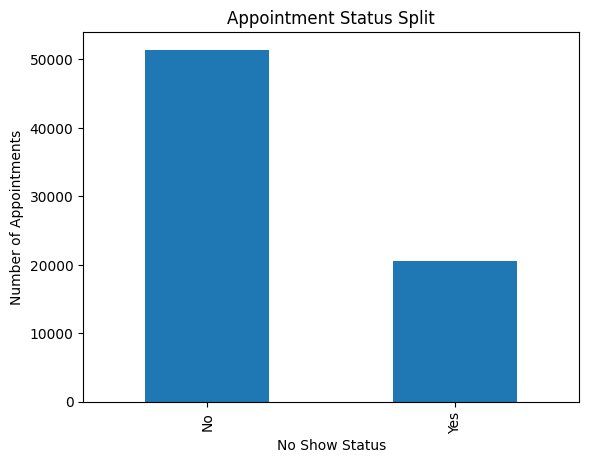

In [105]:
# Count values
status_counts = df['No_show'].value_counts()

# Plot
plt.figure()
status_counts.plot(kind='bar')

# Labels
plt.title('Appointment Status Split')
plt.xlabel('No Show Status')
plt.ylabel('Number of Appointments')

plt.show()

Chart 2

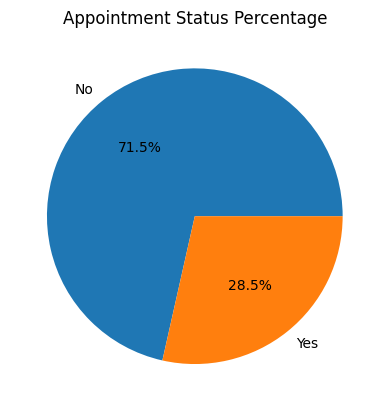

In [106]:
plt.figure()
status_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title('Appointment Status Percentage')

plt.ylabel('')

plt.show()

Chart 3

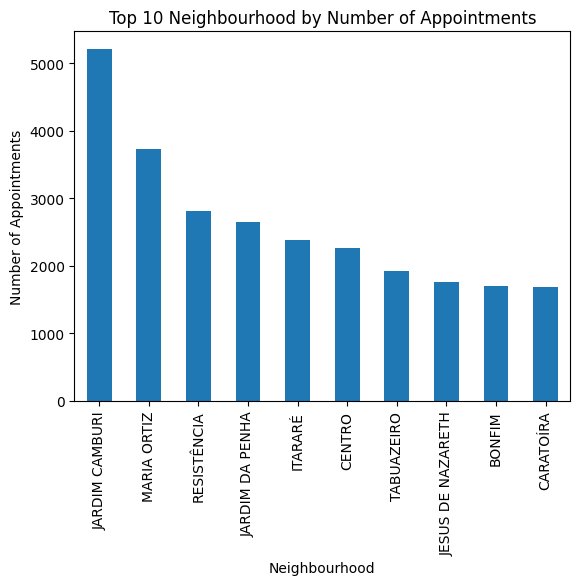

In [107]:
# Top 10 neighbourhood
top10 = df['Neighbourhood'].value_counts().head(10)

# Plot
plt.figure()
top10.plot(kind='bar')

# Labels
plt.title('Top 10 Neighbourhood by Number of Appointments')
plt.xlabel('Neighbourhood')
plt.ylabel('Number of Appointments')

plt.show()

# **Summary**

In [108]:
print("Final Summary:")
print("Total Records:", df.shape[0])
print("Showed:", df['No_show'].value_counts()['No'])
print("No Show:", df['No_show'].value_counts()['Yes'])
print("No Show %:", round(df['No_show'].value_counts(normalize=True)['Yes']*100,2))

Final Summary:
Total Records: 71949
Showed: 51430
No Show: 20519
No Show %: 28.52


# **FINDINGS**



## **1. Total valid records after cleaning**

The original dataset contained over 110,527 records. After cleaning invalid, inconsistent, and incorrect data, 71,949 valid records remained, ensuring accurate analysis.


## **2. Majority of patients attended their appointments**

Out of 71,949 appointments:
51,430 patients attended
20,519 patients did not attend
This means 71.48% showed up and 28.52% missed their appointments.



## **3. Jardim Camburi has the highest number of appointments**

Neighbourhood analysis shows that Jardim Camburi has the highest number of appointments (5,212), indicating higher demand for healthcare services in this area.


## **4. Gurigica has the highest no-show rate**

Gurigica has the highest no-show rate of 38.37%, followed by Jesus de Nazareth and Itararé.
This indicates that patients from these areas are more likely to miss appointments


## **5. No-show rate is significantly high**

The overall no-show rate of 28.52% is considerable, which may lead to inefficient resource utilization and scheduling issues for the hospital.